In [1]:
from loguru import logger
logger.remove()
import sys
logger.add(sys.stderr, level="INFO")

import gc
import numpy as np
import pandas as pd
import xarray as xr
import torch
from pathlib import Path
import itertools

from copy import deepcopy
import matplotlib.colors as mcolors
import colorsys

import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(
    context="paper",
    style="ticks",
    palette="Set2",
    rc={
        "figure.dpi": 500, "savefig.dpi": 500,
        "savefig.bbox": "tight",
        "figure.labelsize": "small",
    },
)

from lib.computation.statistics import cluster_correction
from lib.datasets import load_n_subjects, load_target_var, load_dataset
from lib.analyses.loaders import load_significant_times
from lib.analyses._plots import _plot_generalization, _plot_eigenspectrum, _plot_gen_with_p
from bonner.caching import BONNER_CACHING_HOME
from bonner.computation.decomposition import PCA
from bonner.computation.metrics import covariance, pearson_r
from lib.computation.statistics import compute_p
from bonner.datasets.hebart2022_things_behavior import load_embeddings
from lib.datasets.hebart2022_things_behavior import sort_embeddings
from bonner.datasets.gifford2022_things_eeg_2 import load_metadata

# Import helper functions for memory-efficient loading
from lib._notebook_helpers import (
    get_scorer_kwargs,
    load_generalization_data_streaming,
    load_cvpca_generalization_streaming,
    load_cvpca_generalization_at_time_train,
    add_time_markers,
)

In [2]:
def get_hue_from_color_name(color_name):
    # Get RGB values from matplotlib color name
    rgb = mcolors.to_rgb(color_name)
    
    # Convert RGB to HSV (hue, saturation, value)
    h, s, v = colorsys.rgb_to_hsv(*rgb)
    
    # Convert hue from [0,1] range to [0,359] degrees
    return h * 359

# Get hue values for your colors
forestgreen_hue = get_hue_from_color_name("forestgreen")
indianred_hue = get_hue_from_color_name("indianred")
neg_hue = 270

generalization_dim = "time"

In [3]:
dataset = "things_eeg_2"
subjects = "all"
list_dim = "time"
folds = False
n_permutations = 1000

model_name = "linear"
scorer_kwargs, target_var = get_scorer_kwargs(model_name)
decoding_str = ".subset=False.pca=False"
load_dataset_kwargs = "default"

subpath = Path(f"/data/zchen160/cache/bonner-caching/temporal_dimensionality/main_analyses/behaviorz_tt_decoding_generalization{decoding_str}/dataset={dataset}/load_dataset_kwargs={load_dataset_kwargs}/scorer_kwargs={scorer_kwargs}")

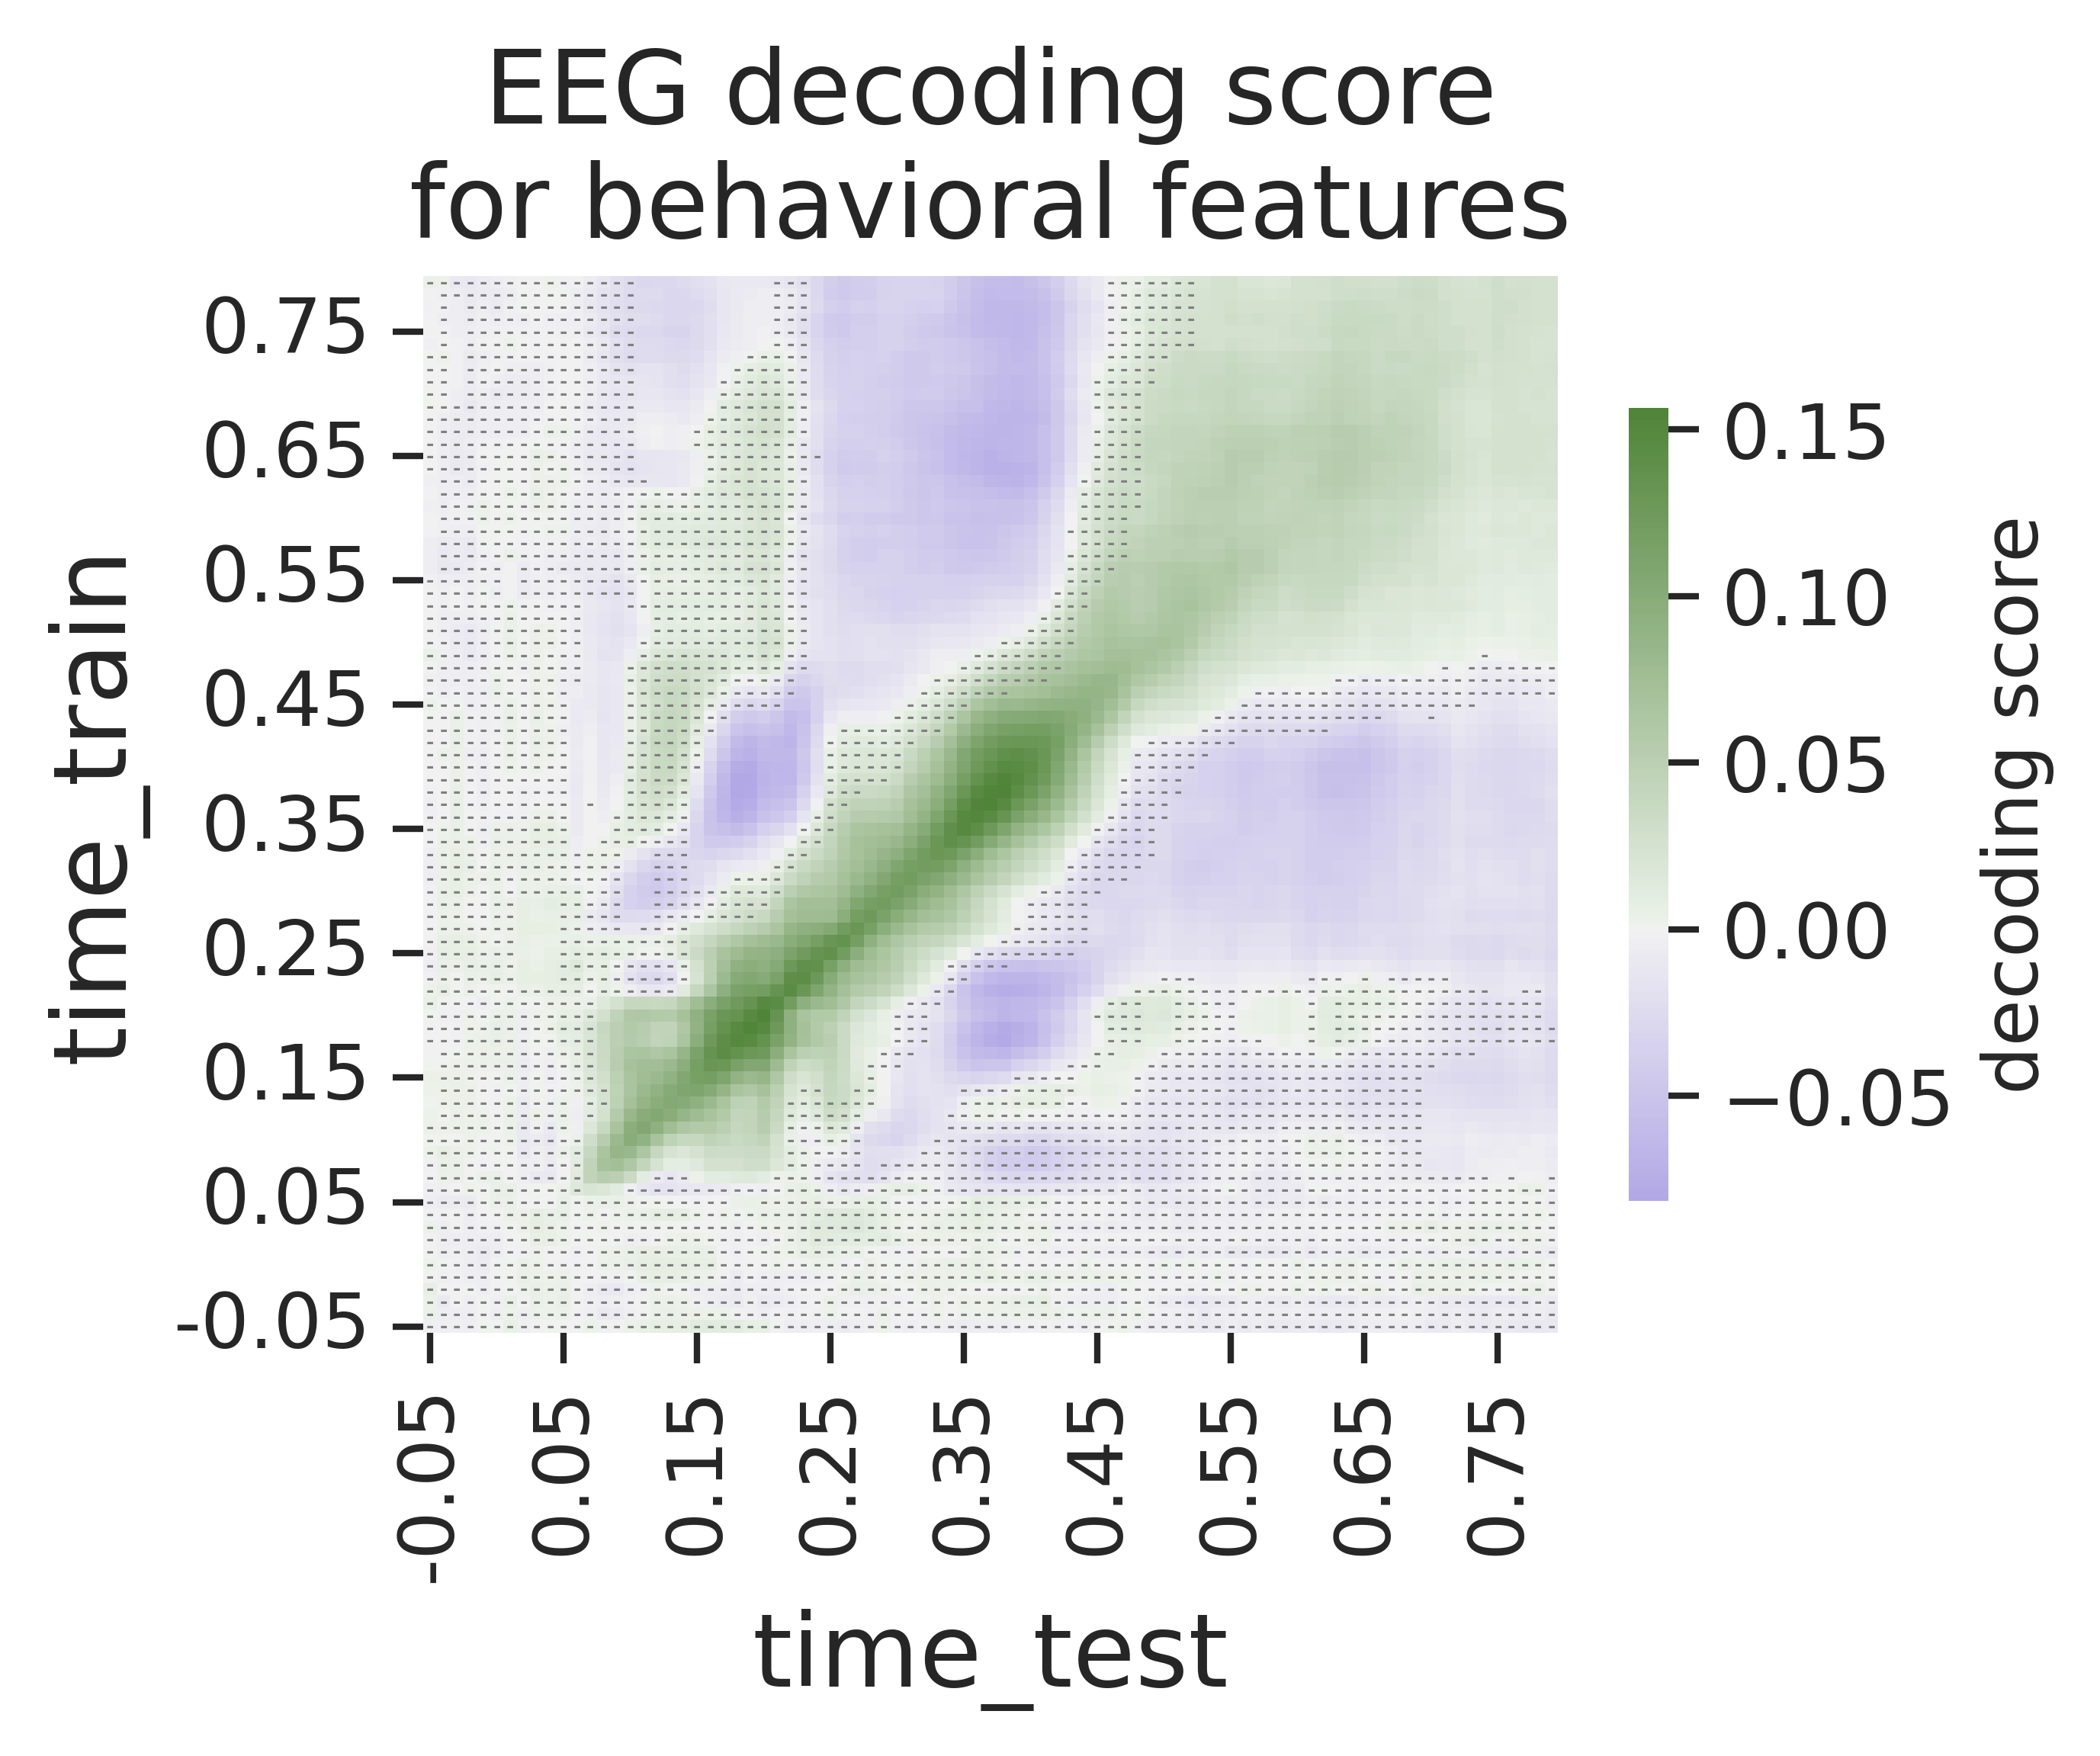

In [5]:
# Load generalization data using memory-efficient streaming
xdf, sig_df = load_generalization_data_streaming(
    subpath, dataset, n_permutations, target_var, time_min=-0.05, folds=folds
)
_plot_gen_with_p(xdf, sig_df, "cvnsr", cache_path=None, cmap=sns.diverging_palette(270, forestgreen_hue, as_cmap=True), cbar_label="decoding score", title="EEG decoding score\nfor behavioral features" if dataset == "things_eeg_2" else "MEG decoding score\nfor behavioral features")

In [6]:
cvpca_path = f"/data/zchen160/cache/bonner-caching/temporal_dimensionality/main_analyses/tt_pca/analysis=behavior/space=eeg.pc_dims=target_var_neuroid.generalization_dim=time.split_dim=presentation.n_splits=2/dataset={dataset}/load_dataset_kwargs={load_dataset_kwargs}/scorer_kwargs=model_name=linear.l2_penalty=0.01/results.nc"

# Load CV-PCA generalization data using memory-efficient streaming
score_df, sig_df = load_cvpca_generalization_streaming(cvpca_path, time_min=-0.05)

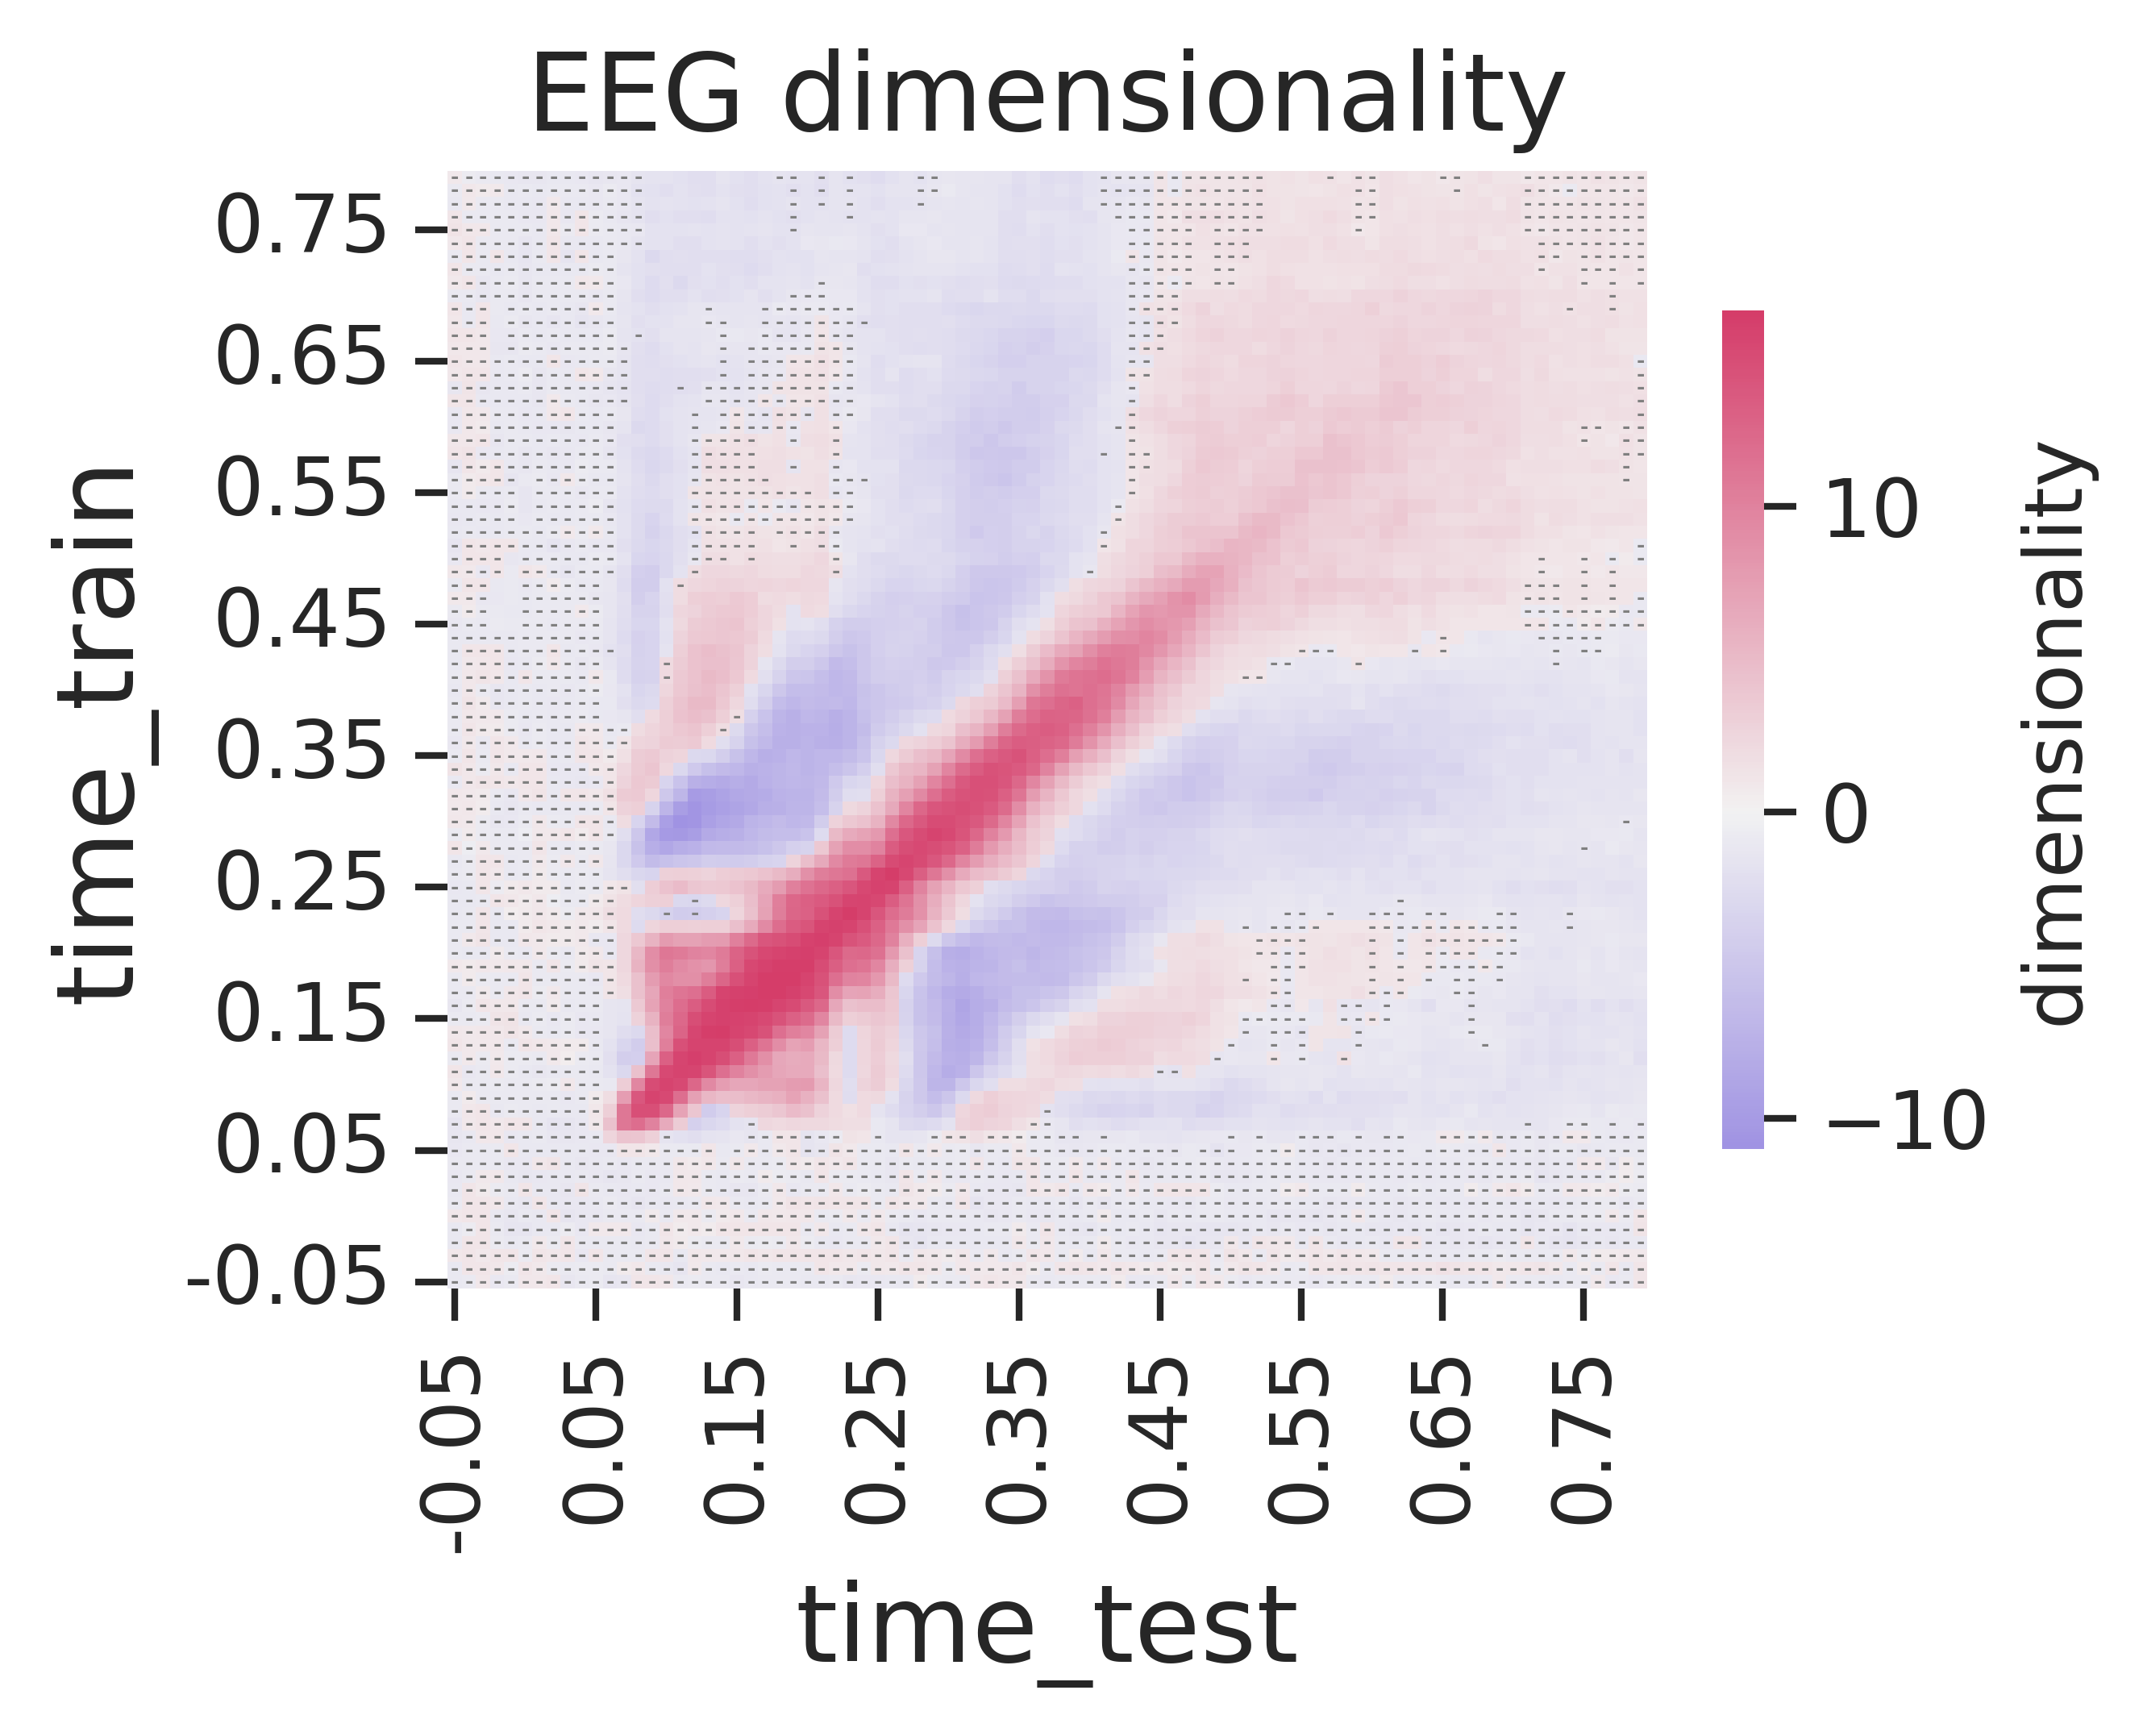

In [7]:
_plot_gen_with_p(score_df, sig_df, "cvnsr", cache_path=None, cmap=sns.diverging_palette(270, indianred_hue, as_cmap=True), cbar_label="dimensionality", title="EEG dimensionality" if dataset == "things_eeg_2" else "MEG dimensionality")

In [6]:
dataset = "things_meg"
subjects = "all"
list_dim = "time"
folds = False

model_name = "linear"
scorer_kwargs, target_var = get_scorer_kwargs(model_name)
decoding_str = ".subset=False.pca=False"
load_dataset_kwargs = "from_raw=1.downsample_freq=100.h_freq=100.baseline=(None, 0).rois=op"

subpath = Path(f"/data/zchen160/cache/bonner-caching/temporal_dimensionality/main_analyses/behaviorz_tt_decoding_generalization{decoding_str}/dataset={dataset}/load_dataset_kwargs={load_dataset_kwargs}/scorer_kwargs={scorer_kwargs}")

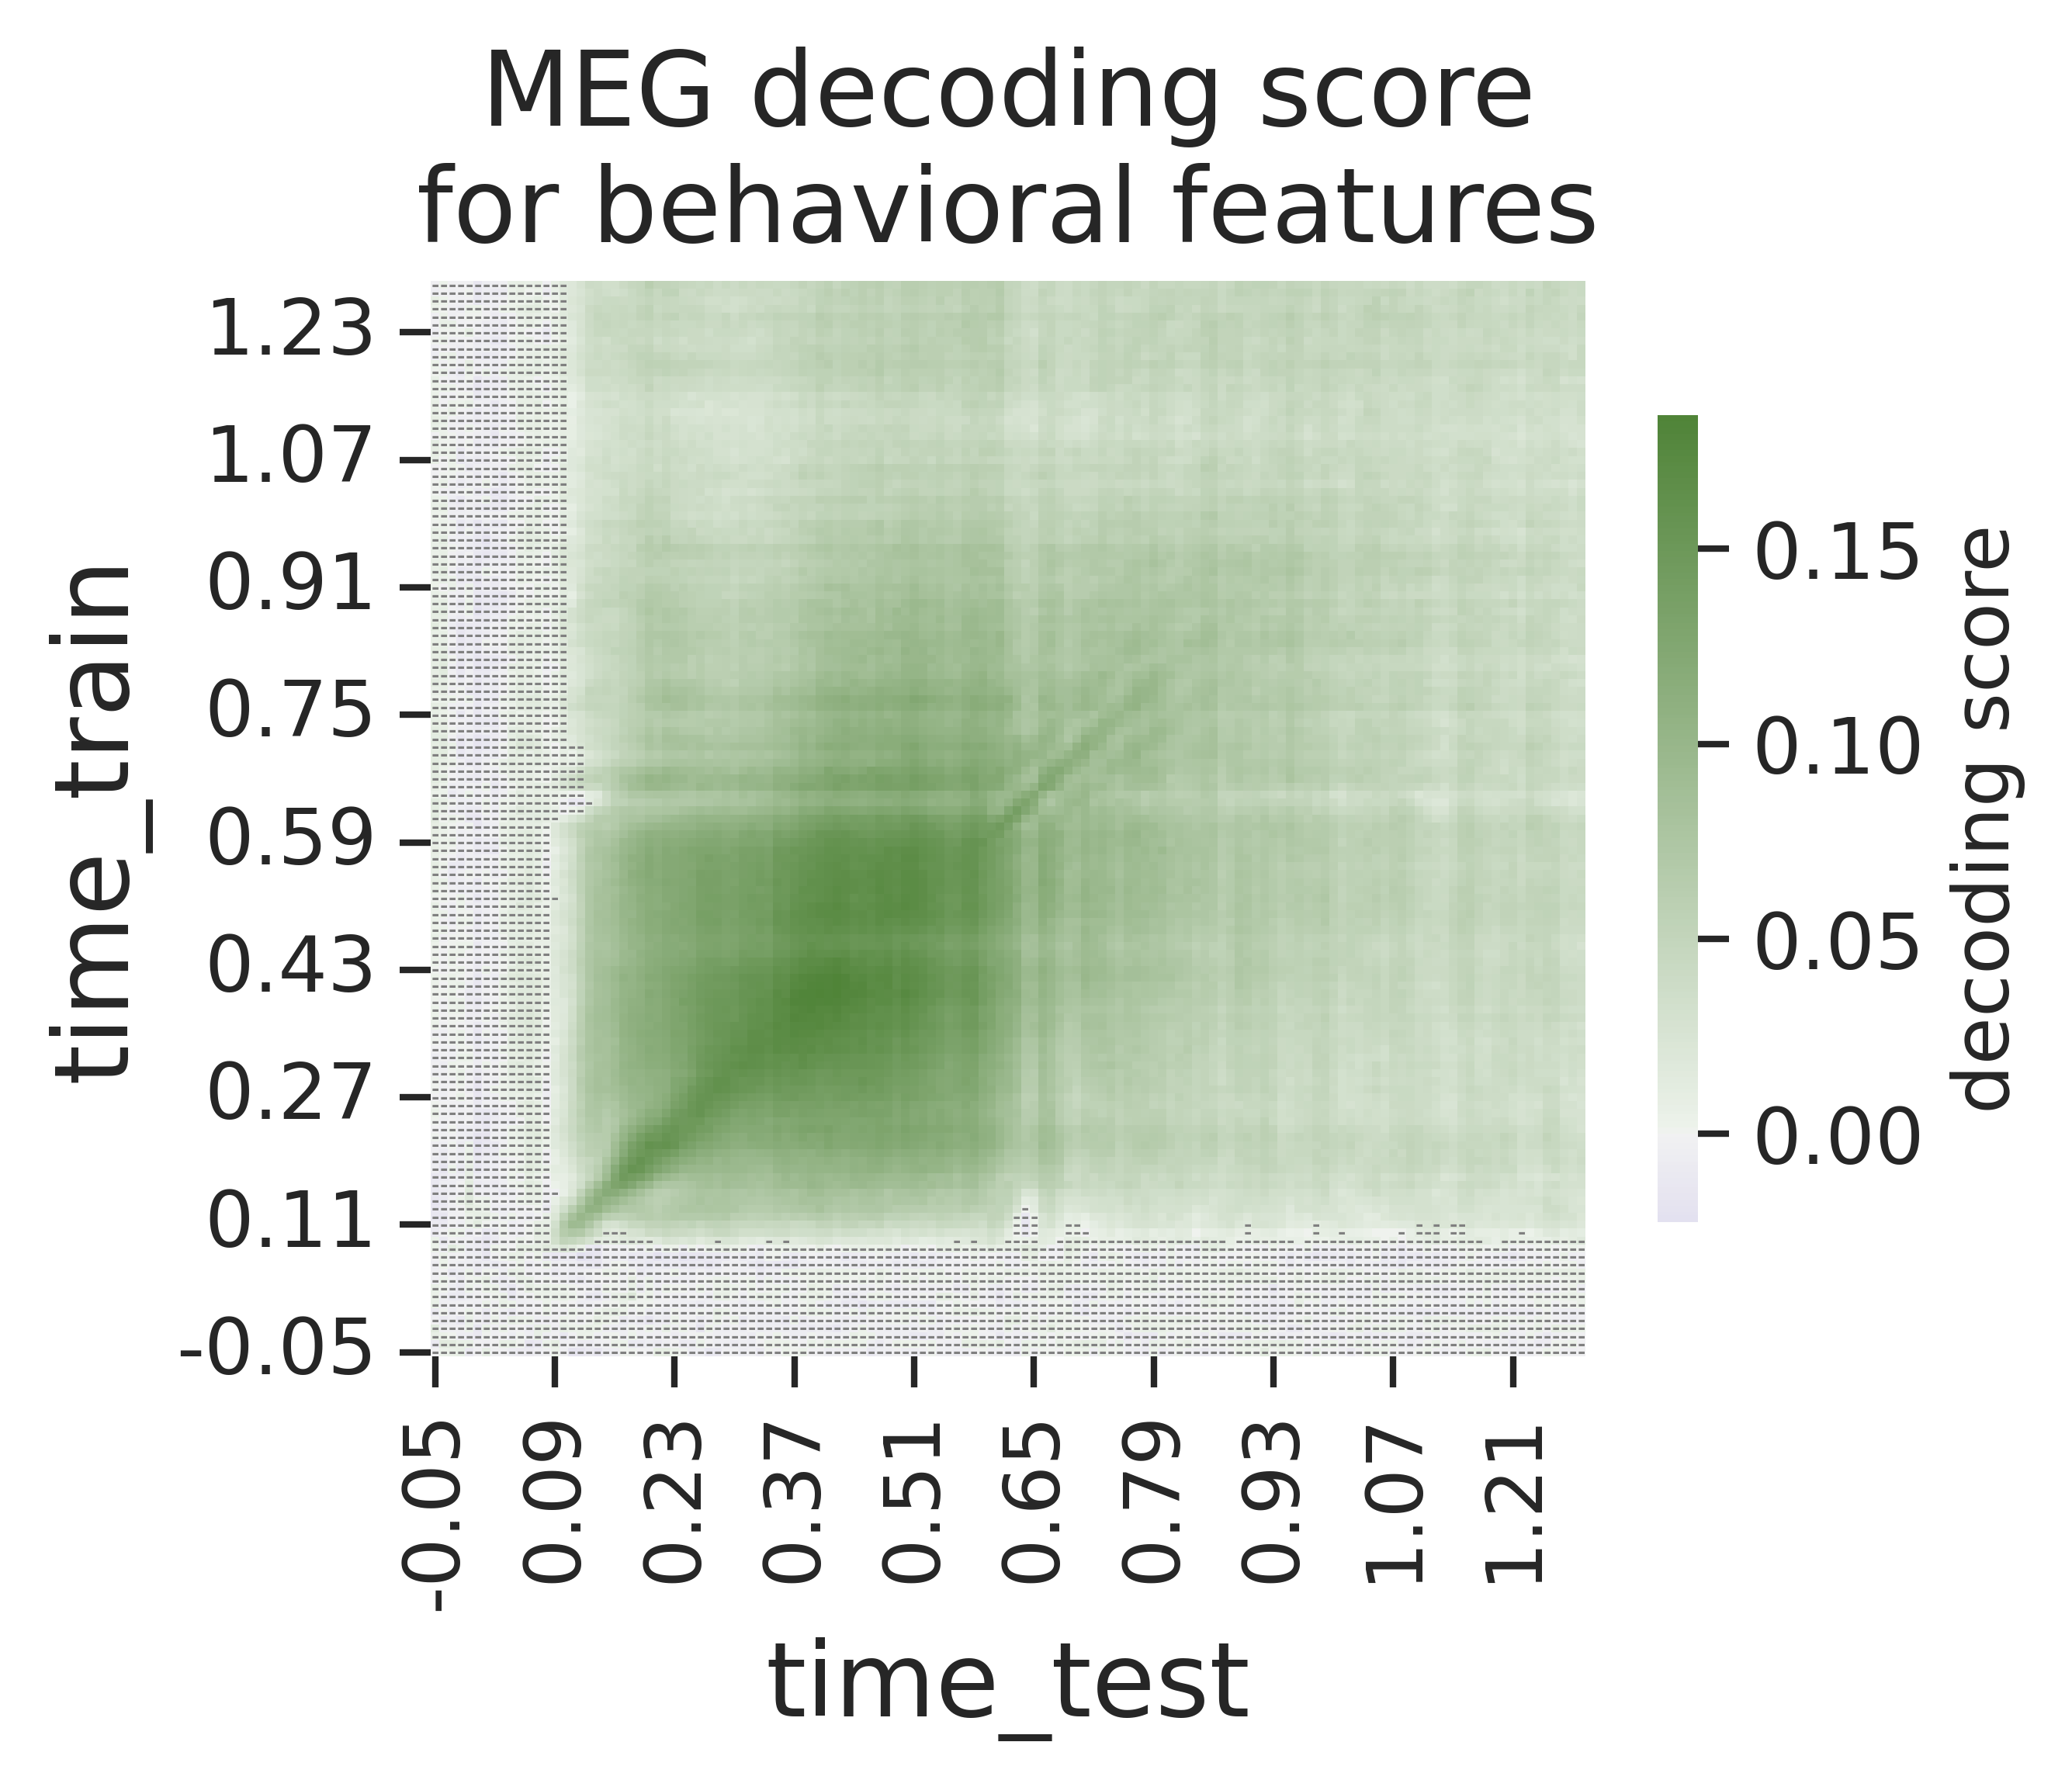

In [7]:
# Load generalization data using memory-efficient streaming
xdf, sig_df = load_generalization_data_streaming(
    subpath, dataset, n_permutations, target_var, time_min=-0.05, folds=folds
)
_plot_gen_with_p(xdf, sig_df, "cvnsr", cache_path=None, cmap=sns.diverging_palette(270, forestgreen_hue, as_cmap=True), cbar_label="decoding score", title="EEG decoding score\nfor behavioral features" if dataset == "things_eeg_2" else "MEG decoding score\nfor behavioral features")

In [10]:
cvpca_path = f"/data/zchen160/cache/bonner-caching/temporal_dimensionality/main_analyses/tt_pca/analysis=behavior/space=eeg.pc_dims=target_var_neuroid.generalization_dim=time.split_dim=presentation.n_splits=2/dataset={dataset}/load_dataset_kwargs={load_dataset_kwargs}/scorer_kwargs=model_name=linear.l2_penalty=0.01/results.nc"

# Load CV-PCA generalization data using memory-efficient streaming
score_df, sig_df = load_cvpca_generalization_streaming(cvpca_path, time_min=-0.05)

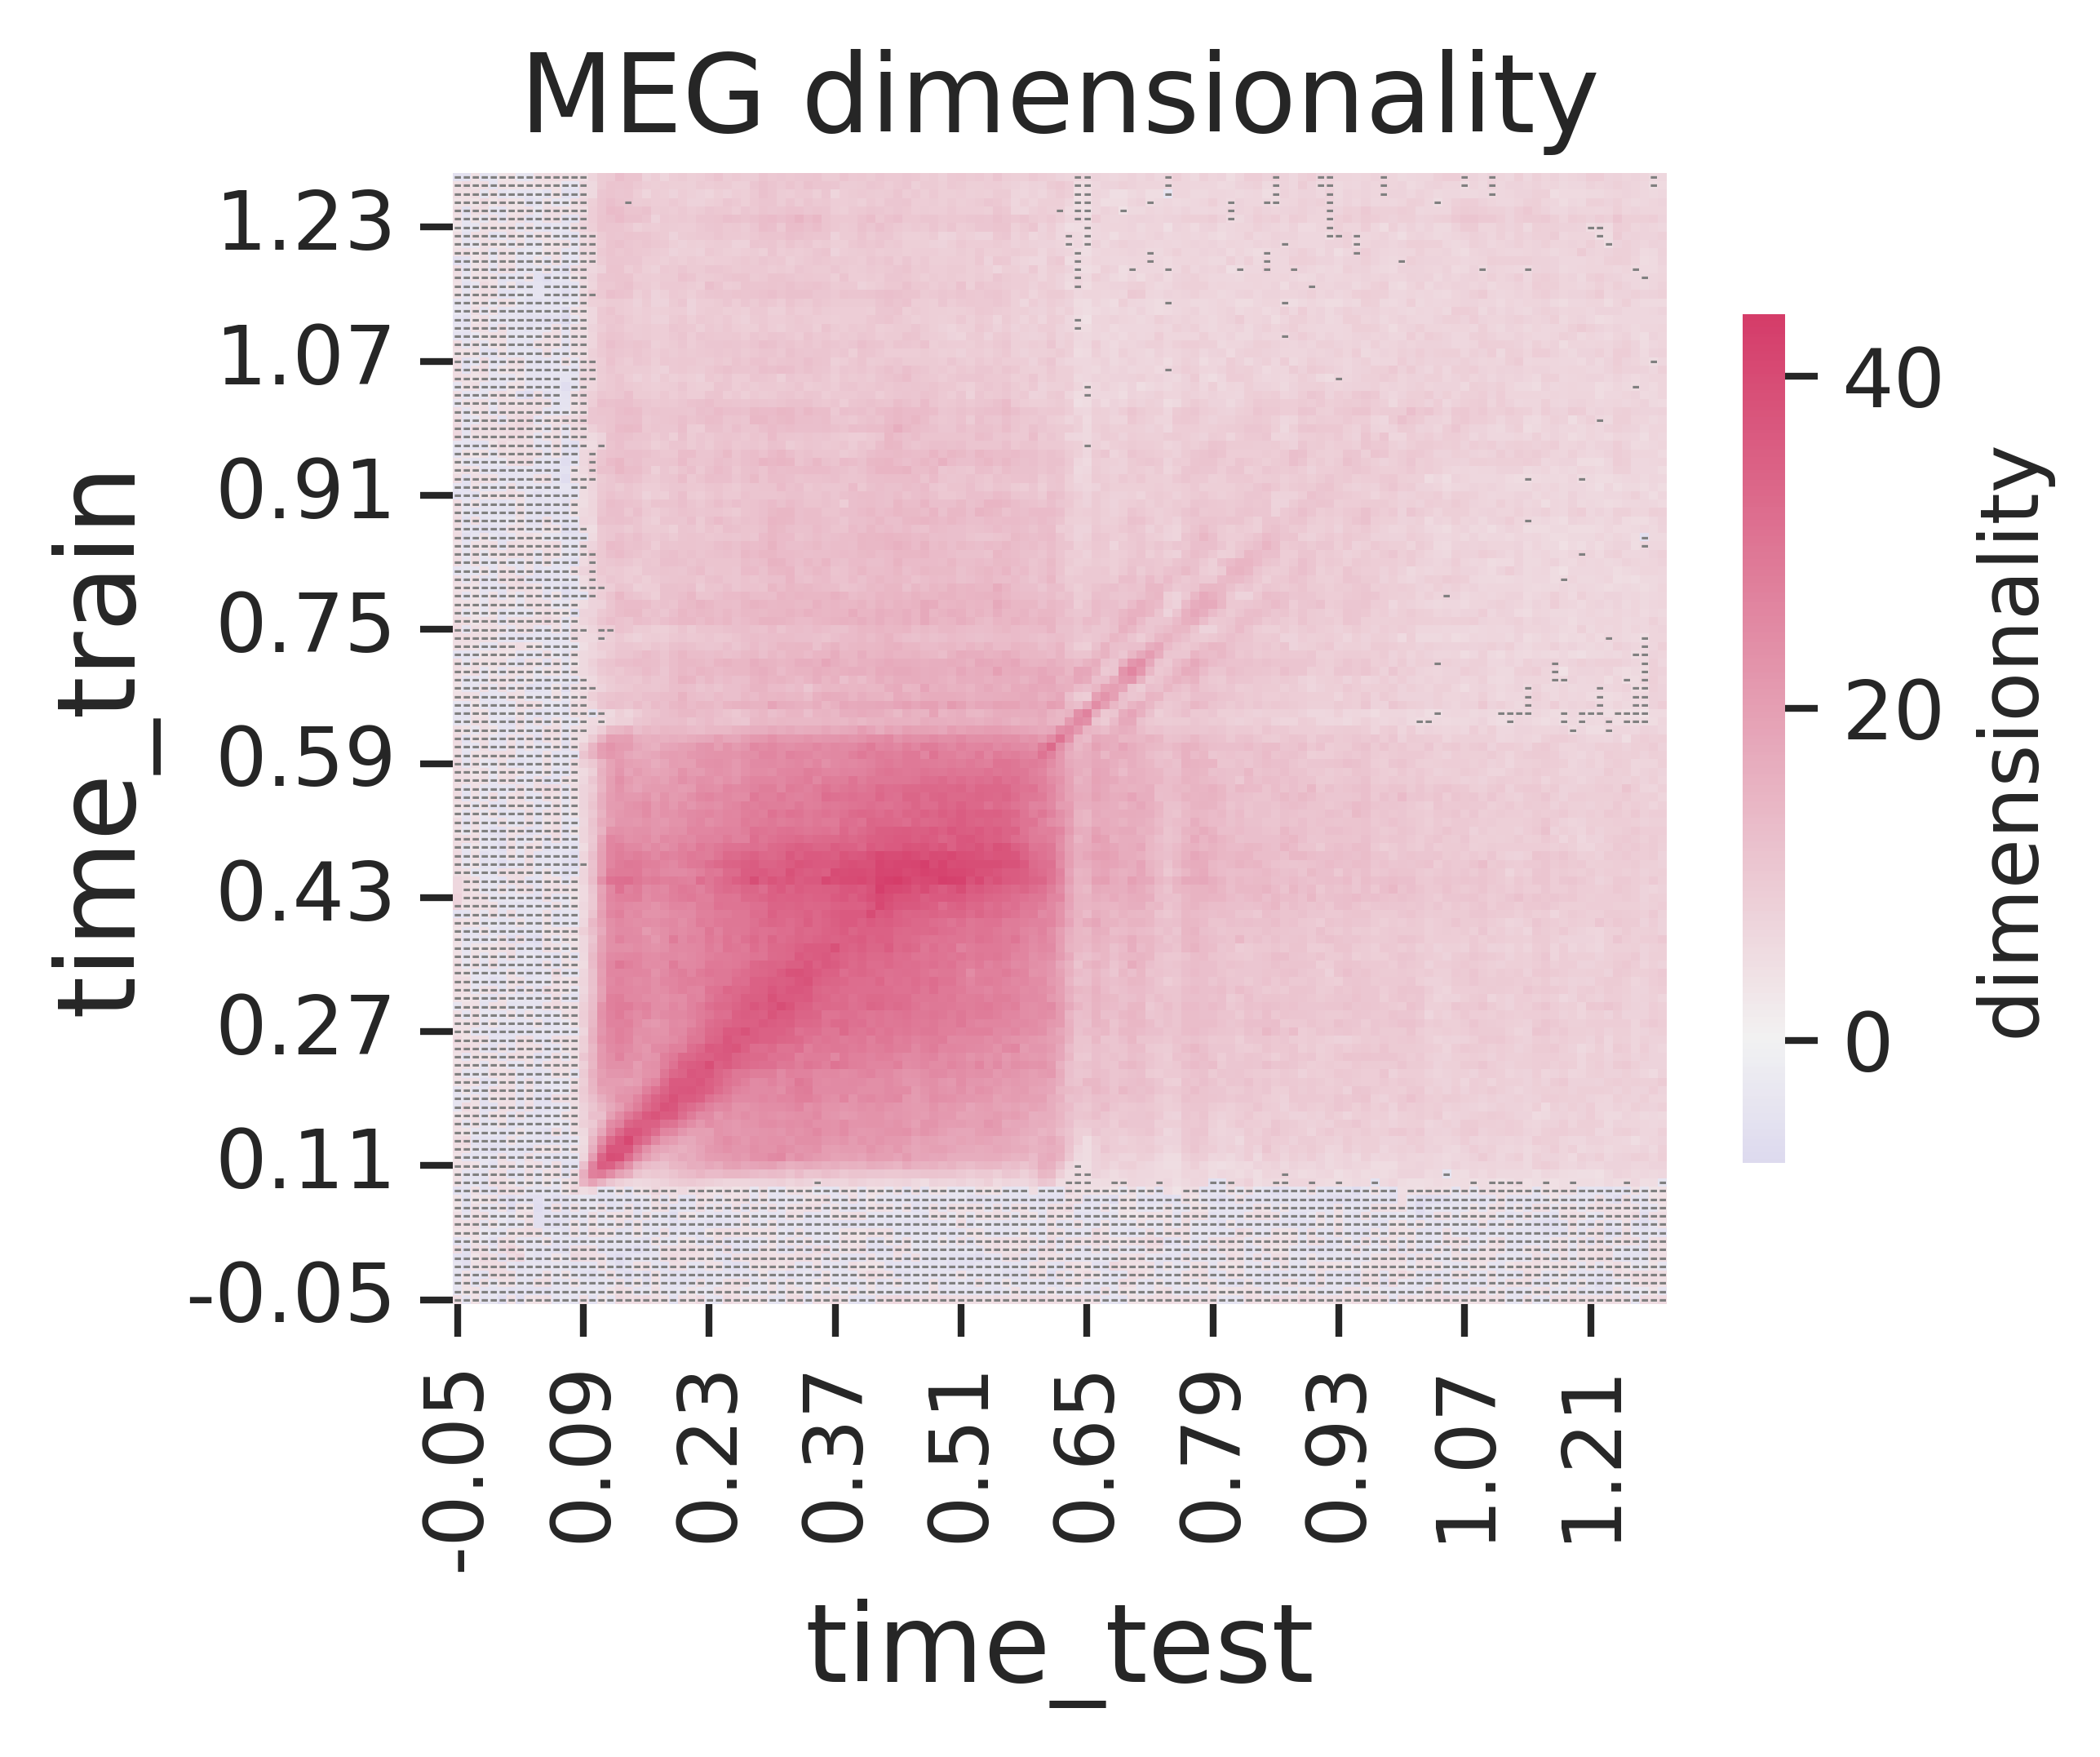

In [11]:
_plot_gen_with_p(score_df, sig_df, "cvnsr", cache_path=None, cmap=sns.diverging_palette(270, indianred_hue, as_cmap=True), cbar_label="dimensionality", title="EEG dimensionality" if dataset == "things_eeg_2" else "MEG dimensionality")

In [4]:
# Configuration for time-slice generalization plots
time_train_values = [0.1, 0.2, 0.3]

# EEG paths
eeg_dataset = "things_eeg_2"
eeg_load_dataset_kwargs = "default"
eeg_cvpca_path = f"/data/zchen160/cache/bonner-caching/temporal_dimensionality/main_analyses/tt_pca/analysis=behavior/space=eeg.pc_dims=target_var_neuroid.generalization_dim=time.split_dim=presentation.n_splits=2/dataset={eeg_dataset}/load_dataset_kwargs={eeg_load_dataset_kwargs}/scorer_kwargs=model_name=linear.l2_penalty=0.01/results.nc"

# MEG paths
meg_dataset = "things_meg"
meg_load_dataset_kwargs = "from_raw=1.downsample_freq=100.h_freq=100.baseline=(None, 0).rois=op"
meg_cvpca_path = f"/data/zchen160/cache/bonner-caching/temporal_dimensionality/main_analyses/tt_pca/analysis=behavior/space=eeg.pc_dims=target_var_neuroid.generalization_dim=time.split_dim=presentation.n_splits=2/dataset={meg_dataset}/load_dataset_kwargs={meg_load_dataset_kwargs}/scorer_kwargs=model_name=linear.l2_penalty=0.01/results.nc"

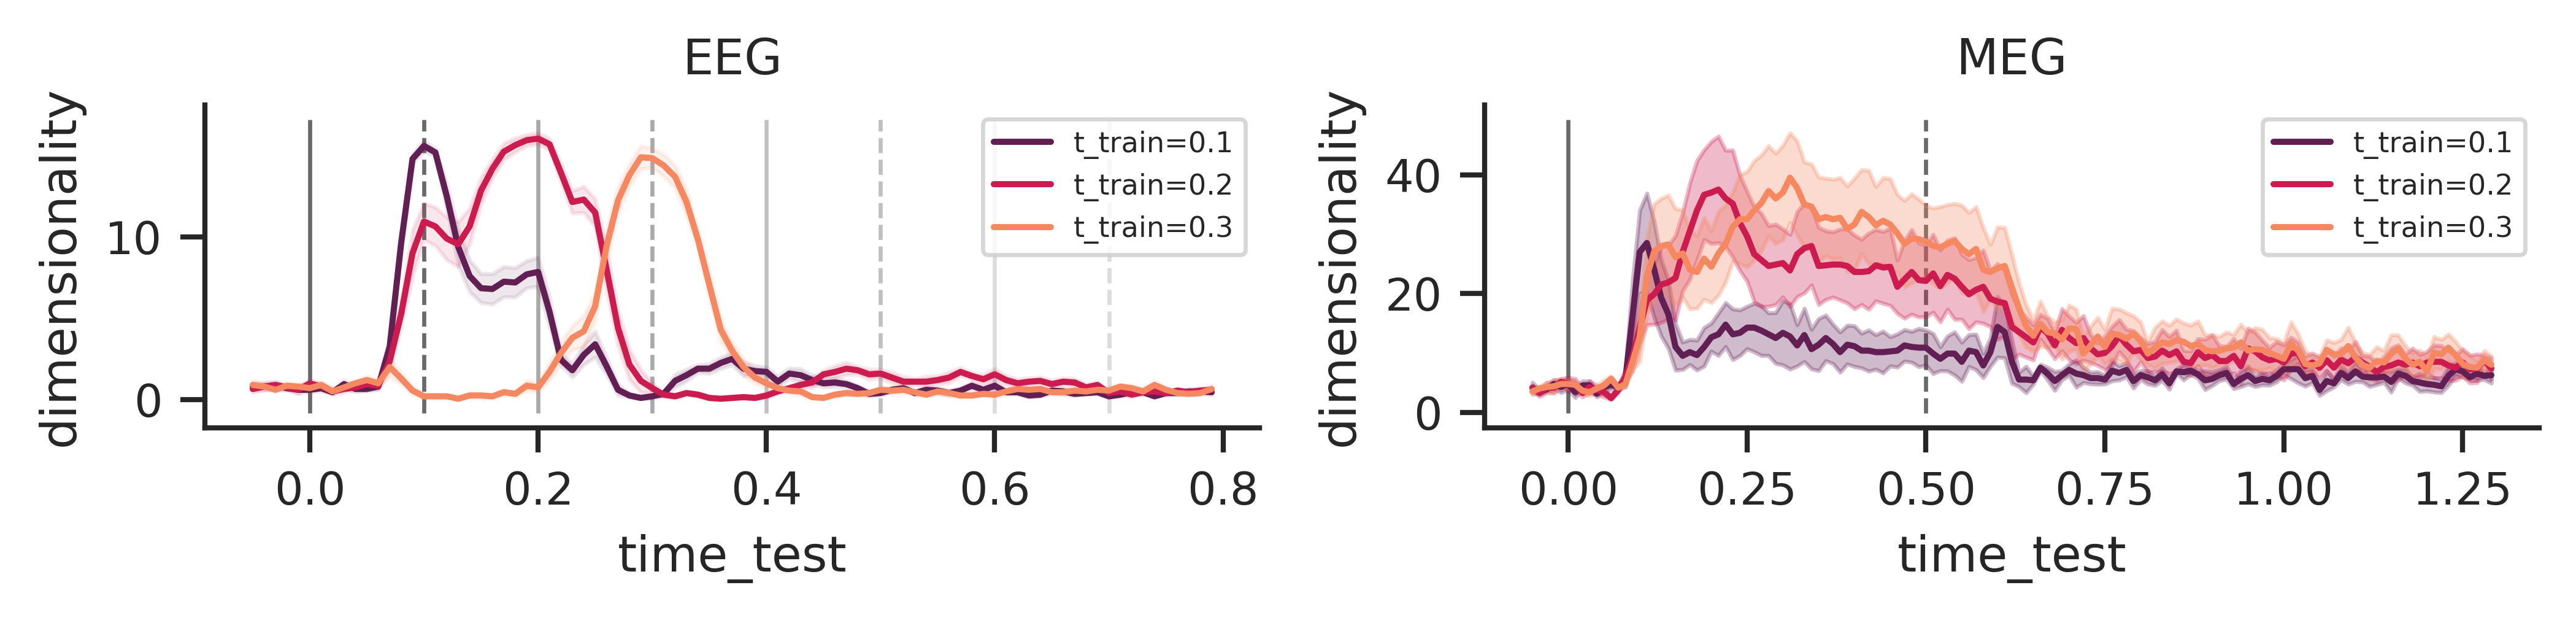

In [5]:
# Single row plot: positive cvnsr only, different time_train values as different hues
plt.close()
width_mm = 180
width_inches = width_mm / 25.4
height_inches = width_inches / 4
fig, axs = plt.subplots(nrows=1, ncols=2, sharex=False, sharey=False, figsize=(width_inches, height_inches))

colors = sns.color_palette("rocket", n_colors=len(time_train_values))

# EEG (left)
ax_eeg = axs[0]
for tt_idx, time_train in enumerate(time_train_values):
    cdf_eeg = load_cvpca_generalization_at_time_train(eeg_cvpca_path, time_train)
    
    sns.lineplot(data=cdf_eeg, x="time", y="pos_cvnsr", ax=ax_eeg, color=colors[tt_idx], 
                 errorbar=None, label=f"t_train={time_train}")
    score = cdf_eeg.groupby(["time", "subject"]).pos_cvnsr.mean().groupby("time").mean().values
    err = cdf_eeg.groupby(["time", "subject"]).pos_cvnsr.mean().groupby("time").sem().values
    ax_eeg.fill_between(cdf_eeg.time.unique(), score - err, score + err, color=colors[tt_idx], alpha=0.1)
    
    del cdf_eeg
    gc.collect()

ax_eeg.set(ylabel="dimensionality", xlabel="time_test")
ax_eeg.set_title("EEG")
ax_eeg.spines['top'].set_visible(False)
ax_eeg.spines['right'].set_visible(False)
ax_eeg.legend(fontsize='xx-small', loc='upper right')

ymin, ymax = ax_eeg.get_ylim()
add_time_markers(ax_eeg, eeg_dataset, ymin, ymax)

# MEG (right)
ax_meg = axs[1]
for tt_idx, time_train in enumerate(time_train_values):
    cdf_meg = load_cvpca_generalization_at_time_train(meg_cvpca_path, time_train)
    
    sns.lineplot(data=cdf_meg, x="time", y="pos_cvnsr", ax=ax_meg, color=colors[tt_idx], 
                 errorbar=None, label=f"t_train={time_train}")
    score = cdf_meg.groupby(["time", "subject"]).pos_cvnsr.mean().groupby("time").mean().values
    err = cdf_meg.groupby(["time", "subject"]).pos_cvnsr.mean().groupby("time").sem().values
    ax_meg.fill_between(cdf_meg.time.unique(), score - err, score + err, color=colors[tt_idx], alpha=0.3)
    
    del cdf_meg
    gc.collect()

ax_meg.set(ylabel="dimensionality", xlabel="time_test")
ax_meg.set_title("MEG")
ax_meg.spines['top'].set_visible(False)
ax_meg.spines['right'].set_visible(False)
ax_meg.legend(fontsize='xx-small', loc='upper right')

ymin, ymax = ax_meg.get_ylim()
add_time_markers(ax_meg, meg_dataset, ymin, ymax)

plt.tight_layout()